'\naxs[2,2].set_title("jy vs t")\naxs[2,2].plot(list_t, j_y)\naxs[2,2].grid()\n'

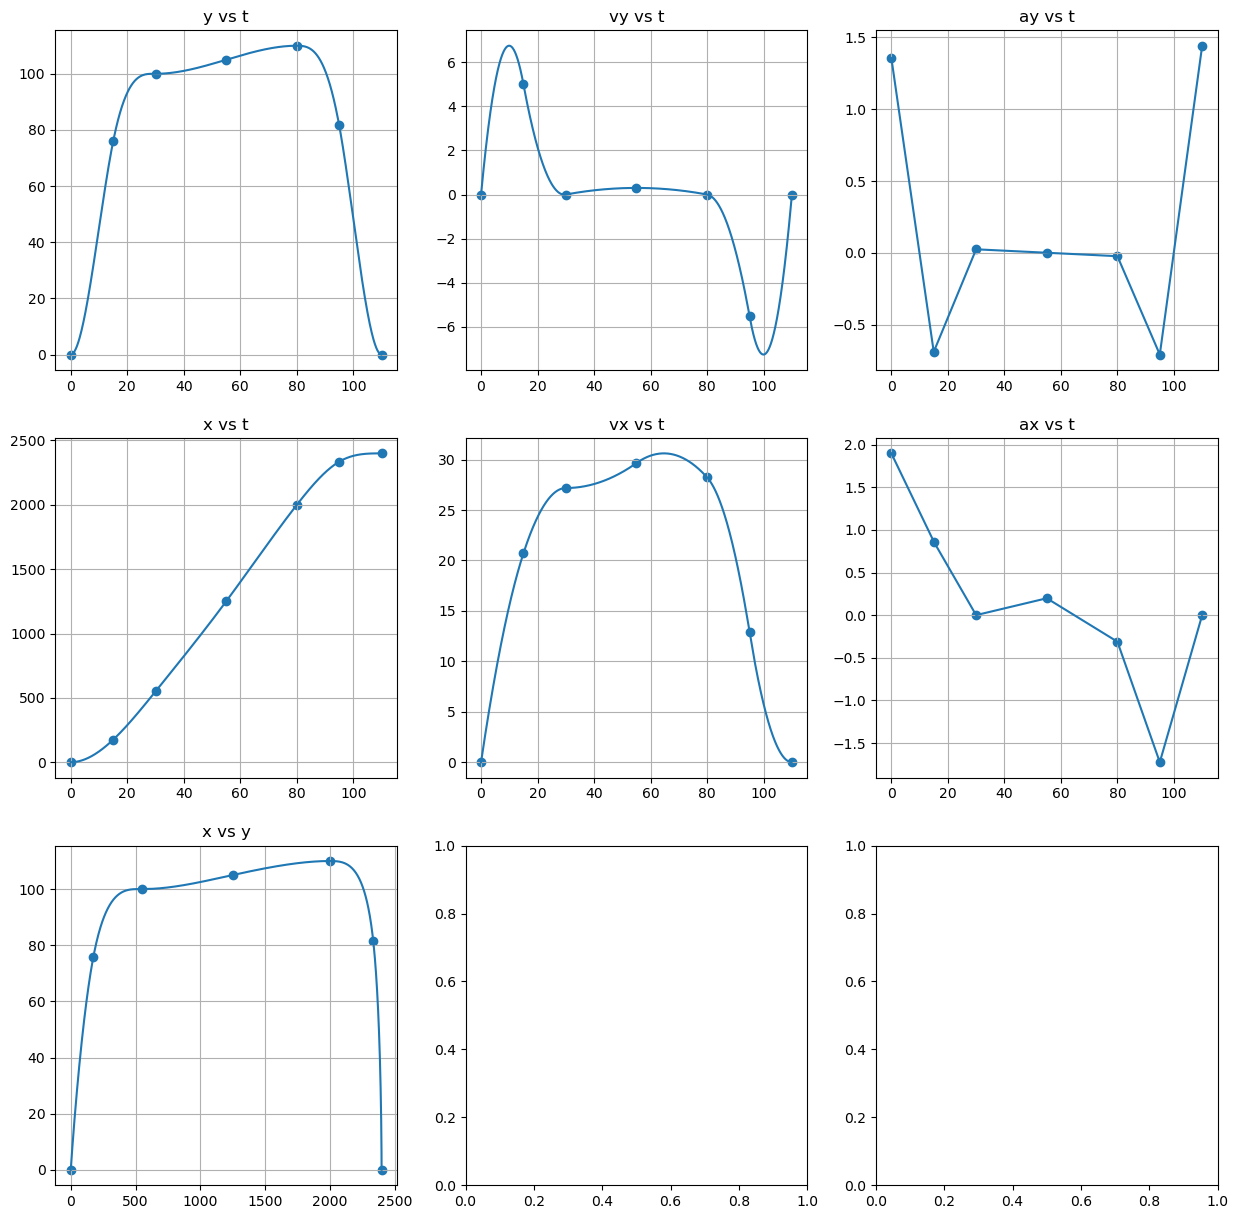

In [9]:
import numpy as np
import matplotlib.pyplot as plt
# from Scripts.mission_profile import MissionProfile
from Scripts.drone_forces import DroneForces
from Scripts.mission_profile import MissionProfileLinearAcc


m1 = MissionProfileLinearAcc("profile")

m1.add_segment(15, "Takeoff")
m1.add_segment(15, "Climb")
m1.add_segment(25, "cruise1")
m1.add_segment(25, "cruise2")
m1.add_segment(15, "decent")
m1.add_segment(15, "land")

# Takeoff
m1.add_constraint(0, "x", 0)
m1.add_constraint(0, "y", 0)
m1.add_constraint(0, "vx", 0)
m1.add_constraint(0, "vy", 0)

# Cruise
m1.add_constraint(550000, "x", 2)
m1.add_constraint(100000, "y", 2)
m1.add_constraint(0, "ax", 2)
m1.add_constraint(0, "vy", 2)
m1.add_constraint(1250000, "x", 3)
m1.add_constraint(105000, "y", 3)
m1.add_constraint(2000000, "x", 4)
m1.add_constraint(110000, "y", 4)
m1.add_constraint(0, "vy", 4)

# Decent
m1.add_constraint(2400000, "x", 6)
m1.add_constraint(0, "y", 6)
m1.add_constraint(0, "vx", 6)
m1.add_constraint(0, "vy", 6)
m1.add_constraint(0, "ax", 6)


m1.solve_kinematics()


list_t = np.arange(0, m1.nodes[-1], 0.1)

x = np.zeros(len(list_t))
y = np.zeros(len(list_t))
v_x = np.zeros(len(list_t))
v_y = np.zeros(len(list_t))
a_x = np.zeros(len(list_t))
a_y = np.zeros(len(list_t))

for i, t in enumerate(list_t):
    p,v,a = m1.time_solve(t)
    x[i] = p[0]
    y[i] = p[1]
    v_x[i] = v[0]
    v_y[i] = v[1]
    a_x[i] = a[0]
    a_y[i] = a[1]

'''
m1 = MissionProfile("m1", 1, 0, 0)

m1.add_segment("takeoff",2,0,2,0,1)
m1.add_segment("climb",15,550000,100000,300,0)
m1.add_segment("cruise",50,2000000,110000,300,0)
m1.add_segment("descent",10,2200000,50000,0,0)
m1.add_segment("loiter",5,2200000,50000,0,0)
m1.add_segment("land",10,2400000,0,0,0)


list_t = np.arange(0, m1.t_values[-1], 0.1)

x = np.zeros(len(list_t))
y = np.zeros(len(list_t))
v_x = np.zeros(len(list_t))
v_y = np.zeros(len(list_t))
a_x = np.zeros(len(list_t))
a_y = np.zeros(len(list_t))
j_x = np.zeros(len(list_t))
j_y = np.zeros(len(list_t))

for i, t in enumerate(list_t):
    x_result, y_result, name = m1.time_solve(t)
    x[i] = x_result[0]
    y[i] = y_result[0]
    v_x[i] = x_result[1]
    v_y[i] = y_result[1]
    a_x[i] = x_result[2]
    a_y[i] = y_result[2]
    j_x[i] = x_result[3]
    j_y[i] = y_result[3]
    
'''

fig, axs = plt.subplots(3, 3)

fig.set_figheight(15)
fig.set_figwidth(15)

axs[0,0].set_title("y vs t")
axs[0,0].plot(list_t, y/1000)
axs[0,0].scatter(m1.nodes,m1.py/1000)
axs[0,0].grid()

axs[1,0].set_title("x vs t")
axs[1,0].plot(list_t, x/1000)
axs[1,0].scatter(m1.nodes,m1.px/1000)
axs[1,0].grid()

axs[2,0].set_title("x vs y")
axs[2,0].plot(x/1000, y/1000)
axs[2,0].scatter(m1.px/1000,m1.py/1000)
axs[2,0].grid()

axs[0,1].set_title("vy vs t")
axs[0,1].plot(list_t, v_y/1000)
axs[0,1].scatter(m1.nodes,m1.vy/1000)
axs[0,1].grid()

axs[1,1].set_title("vx vs t")
axs[1,1].plot(list_t, v_x/1000)
axs[1,1].scatter(m1.nodes,m1.vx/1000)
axs[1,1].grid()
'''
axs[2,1].set_title("jx vs t")
axs[2,1].plot(list_t, j_x)
axs[2,1].grid()
'''
axs[0,2].set_title("ay vs t")
axs[0,2].plot(list_t, a_y/1000)
axs[0,2].scatter(m1.nodes,m1.ay/1000)
axs[0,2].grid()

axs[1,2].set_title("ax vs t")
axs[1,2].plot(list_t, a_x/1000)
axs[1,2].scatter(m1.nodes,m1.ax/1000)
axs[1,2].grid()
'''
axs[2,2].set_title("jy vs t")
axs[2,2].plot(list_t, j_y)
axs[2,2].grid()
'''


 

In [2]:
# Determine masses; moments of inertia; and surface area (for drag)

# Build vehicle coordinate system

# use prop data to determine acceleration; 70% power; 1 dimension 